In [27]:
import os
import cv2
import time
import torch
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import timm
import random

# MONAI imports
import monai
from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    Compose,
    MapTransform,
    Resized,
    RandAffined,
    RandAdjustContrastd,
    NormalizeIntensityd,
    CastToTyped,
    EnsureTyped
)
from monai.losses import FocalLoss
from monai.utils import set_determinism
from monai.transforms import Rand2DElasticd, RandGaussianNoised
from torch.utils.data import WeightedRandomSampler

cv2.setNumThreads(0)

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    set_determinism(seed=seed)

set_global_seed(42)

In [28]:
# ==========================================
# 1. NATIVE MONAI CUSTOM TRANSFORMS
# ==========================================

class LoadAndApplyCLAHEd(MapTransform):
    """
    Custom MONAI dictionary transform to bypass Windows I/O limitations 
    by reading grayscale, applying CLAHE deterministically, and converting 
    to RGB before caching.
    """
    def __init__(self, keys, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img_path = d[key]
            # Read grayscale directly
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                raise ValueError(f"CRITICAL ERROR: Failed to read image at '{img_path}'.")
            
            # Apply CLAHE
            image_clahe = self.clahe.apply(image)
            
            # Convert to RGB
            image_rgb = cv2.cvtColor(image_clahe, cv2.COLOR_GRAY2RGB)
            
            # Convert to channel-first format (C, H, W) for MONAI/PyTorch
            image_ch_first = np.moveaxis(image_rgb, -1, 0)
            
            # Scale to [0, 1] range as standard for NormalizeIntensityd
            d[key] = image_ch_first.astype(np.float32) / 255.0
            
        return d

In [29]:
# ==========================================
# 2. MONAI CACHE DATASET CONFIGURATION
# ==========================================

def get_data_dicts(root_dir, split, classes):
    split_dir = os.path.join(root_dir, split)
    data_dicts = []
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    for cls_name in classes:
        cls_dir = os.path.join(split_dir, cls_name)
        if not os.path.exists(cls_dir):
            continue
            
        for file_name in os.listdir(cls_dir):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(cls_dir, file_name)
                data_dicts.append({"image": img_path, "label": class_to_idx[cls_name]})
                
    return data_dicts

classes = ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

In [30]:
train_transforms = Compose([
    LoadAndApplyCLAHEd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(512, 512)),
    
    RandAffined(keys=["image"], prob=0.8, rotate_range=15 * (np.pi / 180), 
                scale_range=0.1, translate_range=0.05, padding_mode="zeros"),
                
    Rand2DElasticd(keys=["image"], prob=0.5, spacing=(32, 32), magnitude_range=(1, 2)),
    
    RandAdjustContrastd(keys=["image"], prob=0.5, gamma=(0.85, 1.15)),
    
    RandGaussianNoised(keys=["image"], prob=0.5, mean=0.0, std=0.05),
    
    NormalizeIntensityd(keys=["image"], subtrahend=mean, divisor=std, channel_wise=True),
    EnsureTyped(keys=["image", "label"])
])

val_test_transforms = Compose([
    LoadAndApplyCLAHEd(keys=["image"]),
    Resized(keys=["image"], spatial_size=(512, 512)),
    NormalizeIntensityd(keys=["image"], subtrahend=mean, divisor=std, channel_wise=True),
    EnsureTyped(keys=["image", "label"])
])

In [31]:
# ==========================================
# 3. HYPERPARAMETERS & DATA LOADERS
# ==========================================
base_dir = './dataset'

MODEL_SAVE_PATH = "convnextv2_base_ercp_best.pth"

LEARNING_RATE = 2e-5  
WEIGHT_DECAY = 1e-2   
EPOCHS = 60
WARMUP_EPOCHS = 3     
BATCH_SIZE = 4 
ACCUMULATION_STEPS = 2 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

train_data = get_data_dicts(base_dir, 'train', classes)
val_data = get_data_dicts(base_dir, 'val', classes)
test_data = get_data_dicts(base_dir, 'test', classes)



train_labels_list = [item["label"] for item in train_data]
class_counts_array = np.bincount(train_labels_list)
class_weights_array = 1.0 / class_counts_array
sample_weights = [class_weights_array[label] for label in train_labels_list]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
train_dataset = CacheDataset(data=train_data, transform=train_transforms, cache_rate=1.0, num_workers=0)
# shuffle MUST be False when using a sampler
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, num_workers=0, pin_memory=True)



val_dataset = CacheDataset(data=val_data, transform=val_test_transforms, cache_rate=1.0, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

test_dataset = CacheDataset(data=test_data, transform=val_test_transforms, cache_rate=1.0, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Training on device: cuda


Loading dataset: 100%|██████████| 267/267 [00:01<00:00, 192.11it/s]


In [32]:
# ==========================================
# 4. MODEL, LOSS, & OPTIMIZER INITIALIZATION
# ==========================================
print("Loading ConvNeXt V2 Base...")
model = timm.create_model('convnextv2_base', pretrained=True, num_classes=4, drop_rate=0.4, drop_path_rate=0.3)

for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True
    
model = model.to(device)

total_samples = len(train_labels_list)
num_classes = len(classes)

computed_weights = total_samples / (num_classes * class_counts_array)

weights = torch.tensor(computed_weights, dtype=torch.float32).to(device)

criterion = FocalLoss(
    weight=weights, 
    gamma=2.5, 
    reduction='mean',
    to_onehot_y=True,
    use_softmax=True 
)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

best_val_f1 = 0.0

Loading ConvNeXt V2 Base...


Generating DataLoader preview...


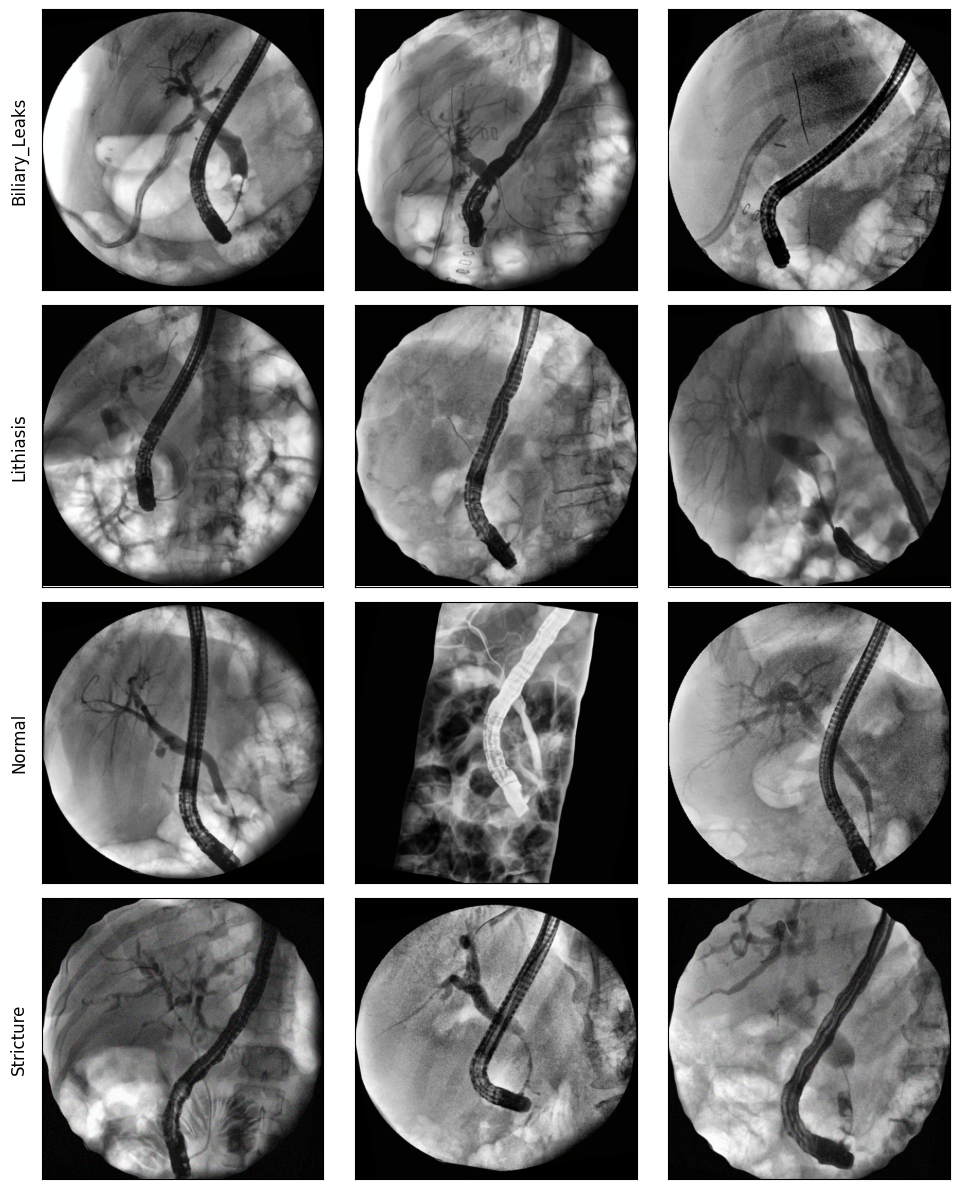

In [33]:
# ==========================================
# VISUALIZE DATALOADER PREVIEW
# ==========================================
def visualize_dataloader_grid(dataloader, class_names, examples_per_class=3):
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np = np.array([0.229, 0.224, 0.225])
    
    num_classes = len(class_names)
    collected_images = {i: [] for i in range(num_classes)}
    
    for batch in dataloader:
        images = batch["image"]
        labels = batch["label"]
        for i in range(len(labels)):
            label = labels[i].item()
            if len(collected_images[label]) < examples_per_class:
                img = images[i].numpy().transpose(1, 2, 0)
                img = std_np * img + mean_np
                img = np.clip(img, 0, 1)
                collected_images[label].append(img)
        
        if all(len(imgs) == examples_per_class for imgs in collected_images.values()):
            break
            
    fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(10, 12))
    
    for cls_idx in range(num_classes):
        for ex_idx in range(examples_per_class):
            if ex_idx < len(collected_images[cls_idx]):
                ax = axes[cls_idx, ex_idx]
                ax.imshow(collected_images[cls_idx][ex_idx])
                ax.set_xticks([])
                ax.set_yticks([])
                if ex_idx == 0:
                    ax.set_ylabel(class_names[cls_idx], fontsize=12, rotation=90, labelpad=10)
                
    plt.tight_layout()
    plt.show()

print("Generating DataLoader preview...")
visualize_dataloader_grid(train_loader, classes)

In [34]:
# ==========================================
# 5. TRAINING & VALIDATION LOOP
# ==========================================
for epoch in range(EPOCHS):
    start_time = time.time()
    
    if epoch == WARMUP_EPOCHS:
        print("\n--- Unfreezing Backbone for Full Fine-Tuning ---")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(EPOCHS - WARMUP_EPOCHS))
    
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    train_preds, train_targets = [], []
    
    optimizer.zero_grad() 
    
    for i, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")):
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device, dtype=torch.long)
        
        # Expand dims to shape [B, 1] to satisfy MONAI's to_onehot_y logic constraints
        labels_onehot = labels.unsqueeze(-1)
        
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels_onehot) 
            loss = loss / ACCUMULATION_STEPS
        
        scaler.scale(loss).backward()
        
        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad() 
        
        running_loss += (loss.item() * ACCUMULATION_STEPS) * inputs.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy()) 
        
    train_f1 = f1_score(train_targets, train_preds, average='macro')
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device, dtype=torch.long)
            labels_onehot = labels.unsqueeze(-1)
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels_onehot)
            
            running_val_loss += loss.item() * inputs.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
    
    val_loss = running_val_loss / len(val_loader.dataset)
    val_f1 = f1_score(val_targets, val_preds, average='macro')
    
    scheduler.step()
    
    time_elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} complete in {time_elapsed:.0f}s | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--> Saved new best model with Val F1: {best_val_f1:.4f}")
        print("\n--- Classification Report ---")
        print(classification_report(val_targets, val_preds, target_names=classes, zero_division=0))

Epoch 1/60 [Val]: 100%|██████████| 59/59 [00:02<00:00, 28.25it/s]


Epoch 1 complete in 39s | Train Loss: 0.2375 | Val Loss: 0.2003 | Train F1: 0.2617 | Val F1: 0.0433
--> Saved new best model with Val F1: 0.0433

--- Classification Report ---
               precision    recall  f1-score   support

Biliary_Leaks       0.10      0.92      0.17        24
    Lithiasis       0.00      0.00      0.00        98
       Normal       0.00      0.00      0.00        59
    Stricture       0.00      0.00      0.00        53

     accuracy                           0.09       234
    macro avg       0.02      0.23      0.04       234
 weighted avg       0.01      0.09      0.02       234



Epoch 2/60 [Val]: 100%|██████████| 59/59 [00:02<00:00, 26.53it/s]


Epoch 2 complete in 40s | Train Loss: 0.2409 | Val Loss: 0.2093 | Train F1: 0.2348 | Val F1: 0.0469
--> Saved new best model with Val F1: 0.0469

--- Classification Report ---
               precision    recall  f1-score   support

Biliary_Leaks       0.10      1.00      0.19        24
    Lithiasis       0.00      0.00      0.00        98
       Normal       0.00      0.00      0.00        59
    Stricture       0.00      0.00      0.00        53

     accuracy                           0.10       234
    macro avg       0.03      0.25      0.05       234
 weighted avg       0.01      0.10      0.02       234



Epoch 3/60 [Val]: 100%|██████████| 59/59 [00:02<00:00, 28.42it/s]


...

Epoch 21 complete in 63s | Train Loss: 0.0032 | Val Loss: 0.4499 | Train F1: 0.9805 | Val F1: 0.5266


Epoch 22/60 [Val]: 100%|██████████| 59/59 [00:02<00:00, 28.31it/s]


Epoch 22 complete in 63s | Train Loss: 0.0038 | Val Loss: 0.3924 | Train F1: 0.9757 | Val F1: 0.5394


Epoch 23/60 [Train]:  31%|███▏      | 84/267 [00:19<00:42,  4.26it/s]


KeyboardInterrupt: 

In [35]:
# ==========================================
# 6. TESTING EVALUATION
# ==========================================
print("\n==========================================")
print("RUNNING FINAL EVALUATION ON TEST SET")
print("==========================================")

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

test_preds, test_targets = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="[Test Set Evaluation]"):
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device, dtype=torch.long)
        
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

print("\n--- Final Test Classification Report ---")
print(classification_report(test_targets, test_preds, target_names=classes, zero_division=0))
test_f1 = f1_score(test_targets, test_preds, average='macro')
print(f"Final Test Macro F1: {test_f1:.4f}")


RUNNING FINAL EVALUATION ON TEST SET


[Test Set Evaluation]: 100%|██████████| 67/67 [00:02<00:00, 27.61it/s]


--- Final Test Classification Report ---
               precision    recall  f1-score   support

Biliary_Leaks       0.77      0.59      0.67        17
    Lithiasis       0.75      0.76      0.76       123
       Normal       0.62      0.65      0.64        43
    Stricture       0.78      0.77      0.78        84

     accuracy                           0.74       267
    macro avg       0.73      0.69      0.71       267
 weighted avg       0.74      0.74      0.74       267

Final Test Macro F1: 0.7091
